In [2]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# -----------------------------
# 1. Define your folders/classes
# -----------------------------
data_dir = "../DATA/Nutrition Food Proj_Cleaned/Nutrition Food Proj -B0-.folder (1)/train"

healthy_classes = [
    "Apple", "Avocado", "Banana", "Beef", "Beef-Fillet", "Beef-Goulash", "Beef-Patty",
    "Blueberry-Yogurt", "Grapes", "Grilled-Chicken-Salad", "Grilled-Pizza", "Ground-Beef",
    "Honey", "Jackfruit", "Kiwi", "Lemon", "Lime", "Lychees", "Mango", "Milk", "Mint",
    "Mozzarella", "Orange", "Pancake", "Papaya", "Parsley", "Passion-Fruit", "Peach",
    "Pear", "Pineapple", "Plum", "Raspberries", "Sandwich", "Strawberries", "Tangerine",
    "Watermelon", "Yogurt", "American-Cheese"
]

unhealthy_classes = [
    "BBQ-Chicken-Pizza", "BBQ-Pizza", "Beef-Pizza", "Beef-Ribs", "Beef-Steak", "Biscuit",
    "Cheese-Pizza", "Chicken-Pizza", "Cupcake", "Donut", "Double-Cheeseburger", "Egg-Roll",
    "Hot-Chocoloate", "Hot-Dog", "Mayonnaise", "Muffin", "Mustard", "Pie", "Sausage-Pizza",
    "Seafood-Pizza", "Vanilla-Yogurt", "Vegetable-Pizza", "Vegetarian-Pizza", "Waffles",
    "Zinger-Burger", "Chocolate-Yogurt", "Strawberry-Jam"
]

# -----------------------------
# 2. Function to extract RGB histogram
# -----------------------------
def extract_color_histogram(image_path, size=(128, 128), bins=8):
    try:
        img = Image.open(image_path).convert("RGB")
        img = img.resize(size)
        img_array = np.array(img)

        # Separate channels
        r = img_array[:, :, 0].flatten()
        g = img_array[:, :, 1].flatten()
        b = img_array[:, :, 2].flatten()

        # Compute normalized histograms
        r_hist, _ = np.histogram(r, bins=bins, range=(0, 256), density=True)
        g_hist, _ = np.histogram(g, bins=bins, range=(0, 256), density=True)
        b_hist, _ = np.histogram(b, bins=bins, range=(0, 256), density=True)

        # Combine into one feature vector
        features = np.concatenate([r_hist, g_hist, b_hist])
        return features

    except Exception as e:
        print(f"Skipping {image_path}: {e}")
        return None

# -----------------------------
# 3. Build dataset
# -----------------------------
X = []
y = []
image_paths = []

for food_class in healthy_classes:
    class_path = os.path.join(data_dir, food_class)
    if os.path.exists(class_path):
        for fname in os.listdir(class_path):
            img_path = os.path.join(class_path, fname)
            features = extract_color_histogram(img_path)
            if features is not None:
                X.append(features)
                y.append(1)   # healthy
                image_paths.append(img_path)

for food_class in unhealthy_classes:
    class_path = os.path.join(data_dir, food_class)
    if os.path.exists(class_path):
        for fname in os.listdir(class_path):
            img_path = os.path.join(class_path, fname)
            features = extract_color_histogram(img_path)
            if features is not None:
                X.append(features)
                y.append(0)   # unhealthy
                image_paths.append(img_path)

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)
print("Healthy images:", np.sum(y == 1))
print("Unhealthy images:", np.sum(y == 0))


Feature matrix shape: (653, 24)
Label vector shape: (653,)
Healthy images: 386
Unhealthy images: 267


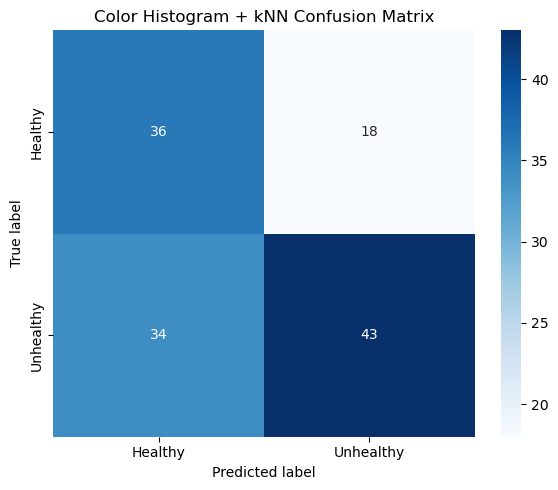

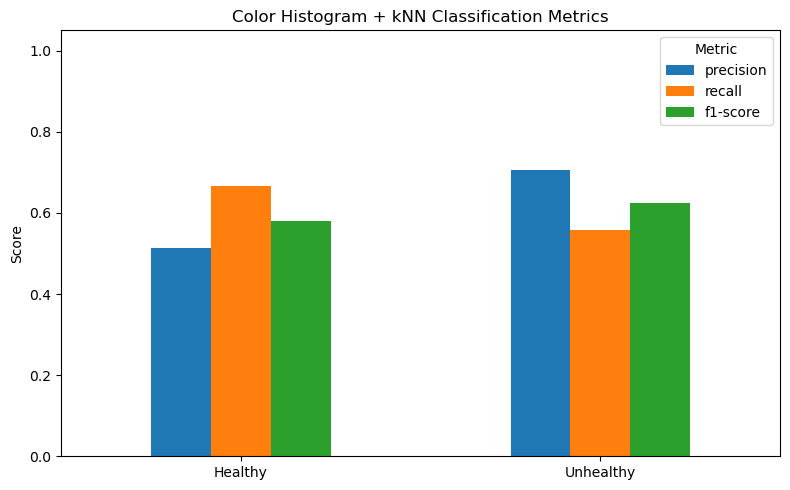

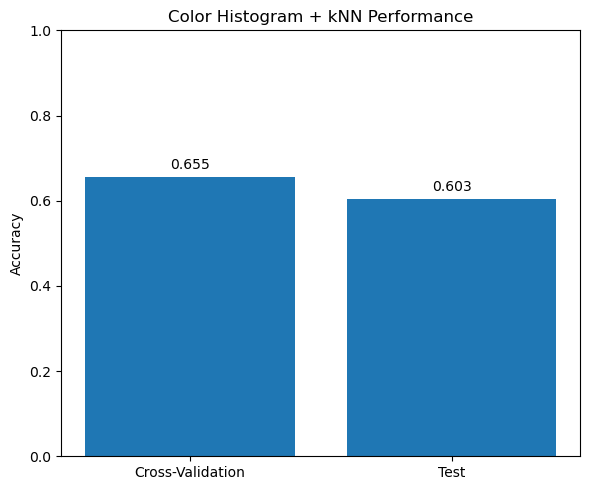

Saved evaluation files to: c:\Users\logan\OneDrive\Documents\DS4002\DS-4002-Project3\DS-4002-Group4Project3\OUTPUT
Saved files:
 - colorhist_knn_confusion_matrix.csv
 - colorhist_knn_classification_report.csv
 - colorhist_knn_evaluation_summary.csv
 - colorhist_knn_confusion_matrix.png
 - colorhist_knn_classification_metrics.png
 - colorhist_knn_accuracy_comparison.png


In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# -----------------------------
# Compute evaluation objects
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report_dict = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()

# -----------------------------
# Save all evaluation tables and visualizations to OUTPUT
# -----------------------------
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
output_dir = os.path.join(repo_root, "OUTPUT")
os.makedirs(output_dir, exist_ok=True)

# 0 = Healthy, 1 = Unhealthy
class_names = ["Healthy", "Unhealthy"]

cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

summary_df = pd.DataFrame({
    "best_cv_accuracy": [grid.best_score_],
    "test_accuracy": [accuracy],
    "test_samples": [int(y_test.shape[0])],
    "best_metric": [grid.best_params_["knn__metric"]],
    "best_n_neighbors": [grid.best_params_["knn__n_neighbors"]],
    "best_weights": [grid.best_params_["knn__weights"]]
})

# Save tables
cm_df.to_csv(os.path.join(output_dir, "colorhist_knn_confusion_matrix.csv"), index=True)
report_df.to_csv(os.path.join(output_dir, "colorhist_knn_classification_report.csv"), index=True)
summary_df.to_csv(os.path.join(output_dir, "colorhist_knn_evaluation_summary.csv"), index=False)

# -----------------------------
# 1. Confusion matrix heatmap
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Color Histogram + kNN Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "colorhist_knn_confusion_matrix.png"))
plt.show()

# -----------------------------
# 2. Classification metrics bar chart
# -----------------------------
label_map = {"0": "Healthy", "1": "Unhealthy"}
metrics_df = report_df.loc[["0", "1"], ["precision", "recall", "f1-score"]].copy()
metrics_df.index = [label_map[idx] for idx in metrics_df.index]

fig, ax = plt.subplots(figsize=(8, 5))
metrics_df.plot(kind="bar", ax=ax)
ax.set_title("Color Histogram + kNN Classification Metrics")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.set_xticklabels(metrics_df.index, rotation=0)
ax.legend(title="Metric")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "colorhist_knn_classification_metrics.png"))
plt.show()

# -----------------------------
# 3. CV vs Test accuracy chart
# -----------------------------
performance_df = pd.DataFrame({
    "Dataset": ["Cross-Validation", "Test"],
    "Accuracy": [grid.best_score_, accuracy]
})

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(performance_df["Dataset"], performance_df["Accuracy"])
ax.set_title("Color Histogram + kNN Performance")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.0)

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.3f}", ha="center")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "colorhist_knn_accuracy_comparison.png"))
plt.show()

print(f"Saved evaluation files to: {output_dir}")
print(
    "Saved files:\n"
    " - colorhist_knn_confusion_matrix.csv\n"
    " - colorhist_knn_classification_report.csv\n"
    " - colorhist_knn_evaluation_summary.csv\n"
    " - colorhist_knn_confusion_matrix.png\n"
    " - colorhist_knn_classification_metrics.png\n"
    " - colorhist_knn_accuracy_comparison.png"
)